# GPU Memory Growth and Importing libraries


In [119]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            if not tf.config.experimental.get_memory_growth(gpu):
                tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled")
    except RuntimeError as e:
        print(e)

print("GPUs:", gpus)

# Then do everything else

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import pandas as pd

Physical devices cannot be modified after being initialized
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [120]:

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


## data preprocessing

### Before Undersampling

In [121]:
training_set=image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)

validation_set=image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [122]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [123]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

## Dataset Overview (Basic EDA)
### We are Checking
1.Number of classes

2.Total images per class

3.Image shape & datatype

In [124]:
import os
import pandas as pd


data_dir = "./val"
classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("validation dataset \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df,"\n\n\n")





data_dir = "./train_original"
classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("training dataset \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df)



validation dataset 

    Class  No_of_Images
0     CNV          7491
1     DME          2319
2  DRUSEN          1773
3  NORMAL         10278 



training dataset 

    Class  No_of_Images
0     CNV         26218
1     DME          8118
2  DRUSEN          6206
3  NORMAL         35973


## Class Distribution Visualization

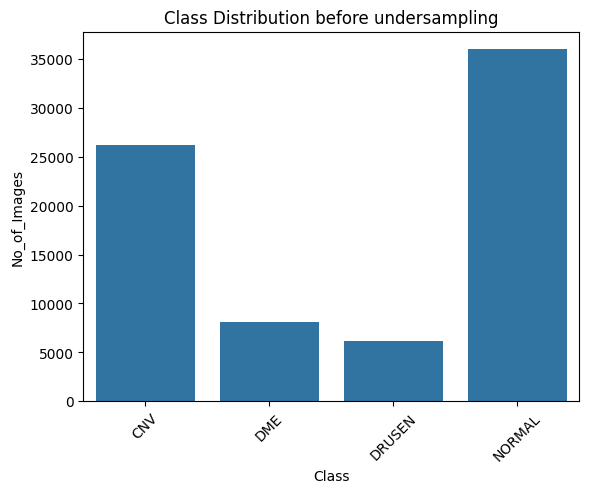

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=df["Class"],y= df["No_of_Images"])
plt.title("Class Distribution before undersampling")
plt.xticks(rotation= 45)
plt.show()

# Undersampling of Data and EDA after undersampling



In [126]:
class_names = training_set.class_names
print(class_names)


['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [127]:
minority_classes = [1, 2]   # DME, DRUSEN


### Undersampling using Kmeans (Time consuming)

#### selects the most distinct images only

In [128]:
# import numpy as np
# import tensorflow as tf
# from pathlib import Path
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from sklearn.cluster import MiniBatchKMeans
# import os

# # ── configuration ─────────────────────────────────────────────────────────────
# TARGET_PER_CLASS = 10_000        # images to keep per class
# EMBED_SIZE       = (32, 32)      # 32×32 = 3,072 dims vs 12,288 at 64×64 — 4× faster KMeans
# SUPPORTED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
# TRAIN_DIR        = "./train"
# NUM_WORKERS      = os.cpu_count()   # parallel threads for image loading

# # DME (8,118) and DRUSEN (6,206) are below target — auto-skipped.
# CLASSES_TO_CHECK = ["CNV", "DME", "DRUSEN", "NORMAL"]


# # ── helpers ───────────────────────────────────────────────────────────────────
# def load_flat(path: Path) -> np.ndarray:
#     """Load one image → flat float32 vector normalised to [0, 1]."""
#     try:
#         raw = tf.io.read_file(str(path))
#         img = tf.image.decode_image(raw, channels=3, expand_animations=False)
#         img = tf.image.resize(img, EMBED_SIZE)
#         return (img.numpy() / 255.0).reshape(-1).astype(np.float32)
#     except Exception:
#         return np.zeros(EMBED_SIZE[0] * EMBED_SIZE[1] * 3, dtype=np.float32)


# def embed_all_parallel(paths: list) -> np.ndarray:
#     """
#     Load and embed all images in parallel using ThreadPoolExecutor.
#     Order is preserved by submitting with index and sorting results.
#     """
#     results = {}
#     with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
#         futures = {pool.submit(load_flat, p): i for i, p in enumerate(paths)}
#         done = 0
#         for future in as_completed(futures):
#             idx = futures[future]
#             results[idx] = future.result()
#             done += 1
#             if done % 2000 == 0:
#                 print(f"    Embedded {done}/{len(paths)} ...")
#     # Reconstruct in original order
#     return np.stack([results[i] for i in range(len(paths))])


# def kmeans_keep_indices(X: np.ndarray, n_keep: int) -> set:
#     """
#     MiniBatchKMeans on X with n_keep clusters.
#     Returns a set of row indices — one per cluster, closest sample to its centre.
#     """
#     print(f"    MiniBatchKMeans k={n_keep} on {X.shape[0]} samples "
#           f"(dims={X.shape[1]}) ...")
#     km = MiniBatchKMeans(
#         n_clusters=n_keep,
#         batch_size=4096,
#         n_init=3,
#         random_state=42,
#         verbose=0,
#     )
#     km.fit(X)

#     keep = set()
#     for c in range(n_keep):
#         members = np.where(km.labels_ == c)[0]
#         if len(members) == 0:
#             continue
#         dists = np.linalg.norm(X[members] - km.cluster_centers_[c], axis=1)
#         keep.add(int(members[np.argmin(dists)]))
#     return keep


# # ── main loop ─────────────────────────────────────────────────────────────────
# for class_name in CLASSES_TO_CHECK:
#     class_dir = Path(TRAIN_DIR) / class_name

#     if not class_dir.is_dir():
#         print(f"[{class_name}] Not found — skipping.")
#         continue

#     all_images = sorted(
#         p for p in class_dir.iterdir()
#         if p.suffix.lower() in SUPPORTED_EXTS
#     )
#     n_total = len(all_images)

#     if n_total <= TARGET_PER_CLASS:
#         print(f"[{class_name}] {n_total} images ≤ {TARGET_PER_CLASS} target — skipping.")
#         continue

#     print(f"\n[{class_name}] {n_total} images → keeping {TARGET_PER_CLASS} "
#           f"(deleting {n_total - TARGET_PER_CLASS})")

#     print(f"  [1/3] Embedding all images in parallel at {EMBED_SIZE} "
#           f"using {NUM_WORKERS} workers ...")
#     X = embed_all_parallel(all_images)

#     print(f"  [2/3] Selecting most diverse {TARGET_PER_CLASS} via KMeans ...")
#     keep_set = kmeans_keep_indices(X, TARGET_PER_CLASS)

#     print(f"  [3/3] Deleting {n_total - len(keep_set)} images from {class_dir} ...")
#     n_deleted = 0
#     for i, img_path in enumerate(all_images):
#         if i not in keep_set:
#             img_path.unlink()   # permanent delete — original folder is your backup
#             n_deleted += 1

#     remaining = len([p for p in class_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS])
#     print(f"[{class_name}] Done. Deleted {n_deleted}. Remaining: {remaining}")

# print("\nUndersampling complete. Run the cells below to train.")


### undersampling using random selection 



In [129]:
import numpy as np
from pathlib import Path

TRAIN_DIR        = "./train"
TARGET_PER_CLASS = 10_000
SUPPORTED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
CLASSES_TO_CHECK = ["CNV", "DME", "DRUSEN", "NORMAL"]

for class_name in CLASSES_TO_CHECK:
    class_dir  = Path(TRAIN_DIR) / class_name
    all_images = sorted(p for p in class_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS)
    n_total    = len(all_images)

    if n_total <= TARGET_PER_CLASS:
        print(f"[{class_name}] {n_total} ≤ {TARGET_PER_CLASS} — skipping.")
        continue

    rng     = np.random.default_rng(seed=42)   # seed=42 makes it reproducible
    to_delete = rng.choice(all_images, size=n_total - TARGET_PER_CLASS, replace=False)

    for p in to_delete:
        p.unlink()

    print(f"[{class_name}] Deleted {len(to_delete)}. Remaining: {TARGET_PER_CLASS}")

print("Done.")

[CNV] 10000 ≤ 10000 — skipping.
[DME] 8118 ≤ 10000 — skipping.
[DRUSEN] 6206 ≤ 10000 — skipping.
[NORMAL] 10000 ≤ 10000 — skipping.
Done.


In [130]:
import os
import pandas as pd


data_dir = "./train"
classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("training dataset after undersampling \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df,"\n\n\n")


training dataset after undersampling 

    Class  No_of_Images
0     CNV         10000
1     DME          8118
2  DRUSEN          6206
3  NORMAL         10000 





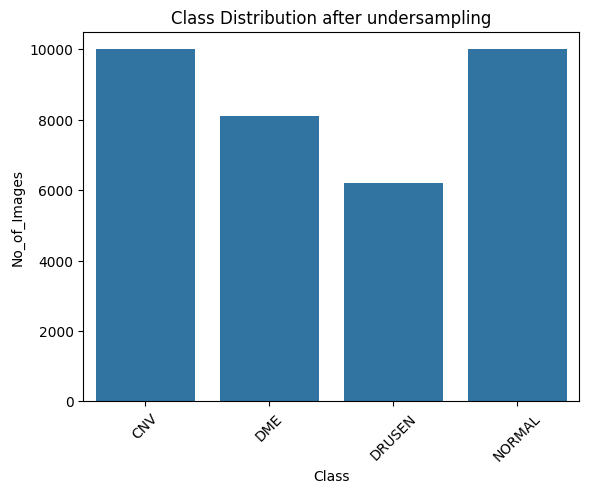

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=df["Class"],y= df["No_of_Images"])
plt.title("Class Distribution after undersampling")
plt.xticks(rotation= 45)
plt.show()

## Setting Parameters for Training on MobileNet V3 Model

In [132]:
training_set=image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)

validation_set=image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [133]:
INPUT_SHAPE=[160,160,3]

In [134]:
mobnet=tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling="avg",
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=False,
    
)


### Adding Layers

In [135]:
#Initialize empty model
model = tf.keras.models.Sequential()

In [136]:
#input layer
model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))

### Normalization


In [137]:
#Normalization
model.add(tf.keras.layers.Rescaling(scale=1./127.5, offset=-1))

In [138]:
# adding mobile net architecture
model.add(mobnet)

In [139]:
# output layers and Dense layers
model.add(tf.keras.layers.Dense(units=4,activation="softmax"))

### Adding Evaluation Metrics

In [140]:
import tensorflow_addons as tfa


number_of_classes= df["Class"].nunique()


metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

In [141]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.CategoricalCrossentropy(),metrics=metrics_list)

In [142]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 MobilenetV3large (Functiona  (None, 960)              2996352   
 l)                                                              
                                                                 
 dense_4 (Dense)             (None, 4)                 3844      
                                                                 
Total params: 3,000,196
Trainable params: 2,975,796
Non-trainable params: 24,400
_________________________________________________________________


In [143]:
#if want to use transfer learning as then the mobile net
#layers weights will be freezed and train only on the dense layers

# mobnet.trainable=False

# GPU

### Check if gpu detected

In [144]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

if gpus:
    print(" GPU is detected")
else:
    print("No GPU detected")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 GPU is detected


# Training


In [145]:
training_history=model.fit(training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
2146/2146 [==============================] - 408s 186ms/step - loss: 0.3646 - accuracy: 0.8685 - f1_score: 0.8582 - precision: 0.8906 - recall: 0.8468 - val_loss: 0.4386 - val_accuracy: 0.8332 - val_f1_score: 0.7875 - val_precision: 0.8372 - val_recall: 0.8291
Epoch 2/15
2146/2146 [==============================] - 317s 148ms/step - loss: 0.1758 - accuracy: 0.9385 - f1_score: 0.9339 - precision: 0.9428 - recall: 0.9345 - val_loss: 0.2024 - val_accuracy: 0.9300 - val_f1_score: 0.8900 - val_precision: 0.9321 - val_recall: 0.9277
Epoch 3/15
2146/2146 [==============================] - 335s 156ms/step - loss: 0.1091 - accuracy: 0.9616 - f1_score: 0.9585 - precision: 0.9639 - recall: 0.9594 - val_loss: 0.1838 - val_accuracy: 0.9428 - val_f1_score: 0.9089 - val_precision: 0.9447 - val_recall: 0.9414
Epoch 4/15
2146/2146 [==============================] - 354s 165ms/step - loss: 0.0701 - accuracy: 0.9760 - f1_score: 0.9740 - precision: 0.9772 - recall: 0.9754 - val_loss: 0.1938 - v

### Seeing the Evaluation Metrics

Found 10932 files belonging to 4 classes.
684/684 [==============================] - 24s 32ms/step - loss: 0.2781 - accuracy: 0.9459 - f1_score: 0.9131 - precision: 0.9467 - recall: 0.9454
              precision    recall  f1-score   support

         CNV       0.99      0.94      0.96      3745
         DME       0.82      0.97      0.89      1161
      DRUSEN       0.79      0.88      0.83       887
      NORMAL       0.98      0.96      0.97      5139

    accuracy                           0.95     10932
   macro avg       0.89      0.94      0.91     10932
weighted avg       0.95      0.95      0.95     10932



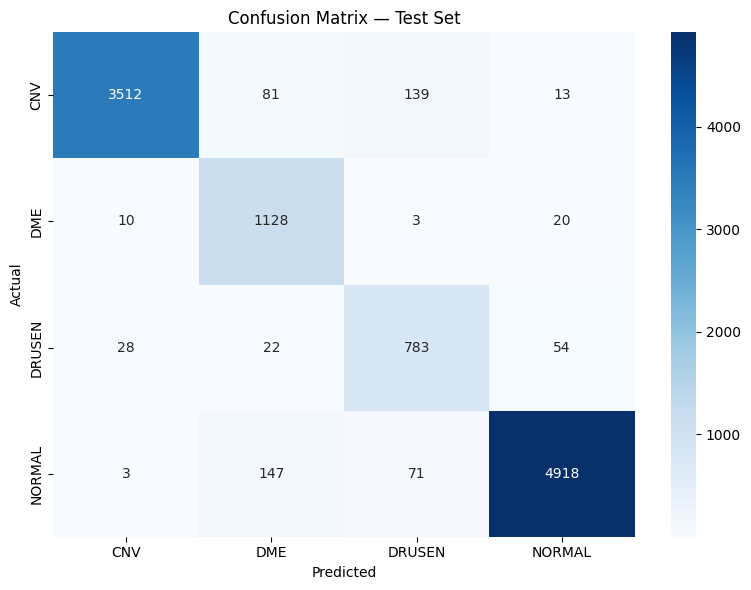

In [158]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_set = image_dataset_from_directory(
    "./test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=False,
)

test_loss, test_accuracy, test_f1_score, test_precision, test_recall = model.evaluate(test_set)
y_true, y_pred = [], []
for images, labels in test_set:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# Saving

In [ ]:
model.save("trained_eye.keras")
training_history.history

{'loss': [0.3646214008331299,
  0.17580322921276093,
  0.10912449657917023,
  0.07014529407024384,
  0.049662839621305466,
  0.0404420904815197,
  0.03409118577837944,
  0.029399452731013298,
  0.02478569932281971,
  0.024074003100395203,
  0.02422204241156578,
  0.021221596747636795,
  0.018968237563967705,
  0.01888320781290531,
  0.017574796453118324],
 'accuracy': [0.8685467839241028,
  0.9384978413581848,
  0.9616303443908691,
  0.9759934544563293,
  0.9826943278312683,
  0.9857242703437805,
  0.9890455603599548,
  0.9889873266220093,
  0.9912306070327759,
  0.99111407995224,
  0.9912889003753662,
  0.9922794699668884,
  0.9928038716316223,
  0.9928621649742126,
  0.9932700395584106],
 'f1_score': [0.8581869602203369,
  0.9338632822036743,
  0.9585456848144531,
  0.9739981889724731,
  0.9812405109405518,
  0.9846752882003784,
  0.9882256984710693,
  0.9881699085235596,
  0.9905706644058228,
  0.9904212355613708,
  0.9906508922576904,
  0.9916924834251404,
  0.9923180937767029,
  0

In [ ]:
#saving history
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(training_history.history,f)

# using saved model

## reloading history from pickel file

In [ ]:
model=tf.keras.models.load_model("trained_eye.keras")

In [ ]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 MobilenetV3large (Functiona  (None, 960)              2996352   
 l)                                                              
                                                                 
 dense_4 (Dense)             (None, 4)                 3844      
                                                                 
Total params: 3,000,196
Trainable params: 2,975,796
Non-trainable params: 24,400
_________________________________________________________________


In [ ]:
import pickle
with open("training_history.pkl", "rb") as f:
    load_history = pickle.load(f)

print(load_history)    

{'loss': [0.3646214008331299, 0.17580322921276093, 0.10912449657917023, 0.07014529407024384, 0.049662839621305466, 0.0404420904815197, 0.03409118577837944, 0.029399452731013298, 0.02478569932281971, 0.024074003100395203, 0.02422204241156578, 0.021221596747636795, 0.018968237563967705, 0.01888320781290531, 0.017574796453118324], 'accuracy': [0.8685467839241028, 0.9384978413581848, 0.9616303443908691, 0.9759934544563293, 0.9826943278312683, 0.9857242703437805, 0.9890455603599548, 0.9889873266220093, 0.9912306070327759, 0.99111407995224, 0.9912889003753662, 0.9922794699668884, 0.9928038716316223, 0.9928621649742126, 0.9932700395584106], 'f1_score': [0.8581869602203369, 0.9338632822036743, 0.9585456848144531, 0.9739981889724731, 0.9812405109405518, 0.9846752882003784, 0.9882256984710693, 0.9881699085235596, 0.9905706644058228, 0.9904212355613708, 0.9906508922576904, 0.9916924834251404, 0.9923180937767029, 0.9922246336936951, 0.992793083190918], 'precision': [0.890580952167511, 0.9427739977

In [ ]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'precision', 'recall', 'val_loss', 'val_accuracy', 'val_f1_score', 'val_precision', 'val_recall'])

### loss visualisation

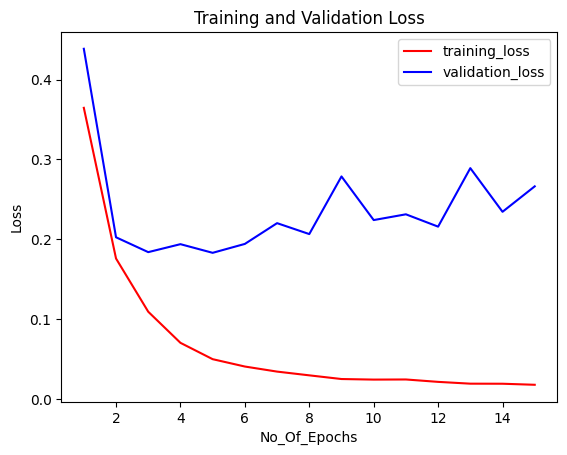

In [ ]:
epochs=[i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red' ,label="training_loss")
plt.plot(epochs,load_history['val_loss'],color='blue' ,label="validation_loss")
plt.xlabel("No_Of_Epochs") 
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()
